In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import folium
from folium.plugins import MarkerCluster, HeatMap
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from statsmodels.tsa.seasonal import seasonal_decompose
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
import string
import os
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.cluster import KMeans


In [3]:
import pandas as pd
xls_file_path = '../data/Global Terrorism Database May 2022.xlsx'
df = pd.read_excel(xls_file_path)


In [4]:
# Write the DataFrame to a CSV file
csv_file_path = '../data/Global_Terrorism_Database_May_2022.csv'
df.to_csv(csv_file_path, index=False)

In [5]:
# Print all column names
for column in df.columns:
    print(column)

eventid
iyear
imonth
iday
approxdate
extended
resolution
country
country_txt
region
region_txt
provstate
city
latitude
longitude
specificity
vicinity
location
summary
crit1
crit2
crit3
doubtterr
alternative
alternative_txt
multiple
success
suicide
attacktype1
attacktype1_txt
attacktype2
attacktype2_txt
attacktype3
attacktype3_txt
targtype1
targtype1_txt
targsubtype1
targsubtype1_txt
corp1
target1
natlty1
natlty1_txt
targtype2
targtype2_txt
targsubtype2
targsubtype2_txt
corp2
target2
natlty2
natlty2_txt
targtype3
targtype3_txt
targsubtype3
targsubtype3_txt
corp3
target3
natlty3
natlty3_txt
gname
gsubname
gname2
gsubname2
gname3
gsubname3
motive
guncertain1
guncertain2
guncertain3
individual
nperps
nperpcap
claimed
claimmode
claimmode_txt
claim2
claimmode2
claimmode2_txt
claim3
claimmode3
claimmode3_txt
compclaim
weaptype1
weaptype1_txt
weapsubtype1
weapsubtype1_txt
weaptype2
weaptype2_txt
weapsubtype2
weapsubtype2_txt
weaptype3
weaptype3_txt
weapsubtype3
weapsubtype3_txt
weaptype4
weapt

In [ ]:
# Generate summary statistics
summary_stats = df.describe(include='all')
print("Summary Statistics:")
print(summary_stats)

# Check data types of each column
data_types = df.dtypes
print("\nData Types:")
print(data_types)

In [7]:
# Identify missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a DataFrame for better readability
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

print("Missing Values Analysis:")
print(missing_data)

Missing Values Analysis:
                  Missing Values  Percentage
gsubname3                 209683   99.989032
weapsubtype4              209636   99.966620
weapsubtype4_txt          209636   99.966620
weaptype4_txt             209633   99.965189
weaptype4                 209633   99.965189
...                          ...         ...
city                         427    0.203618
guncertain1                  380    0.181206
ishostkid                    178    0.084881
specificity                    1    0.000477
multiple                       1    0.000477

[104 rows x 2 columns]


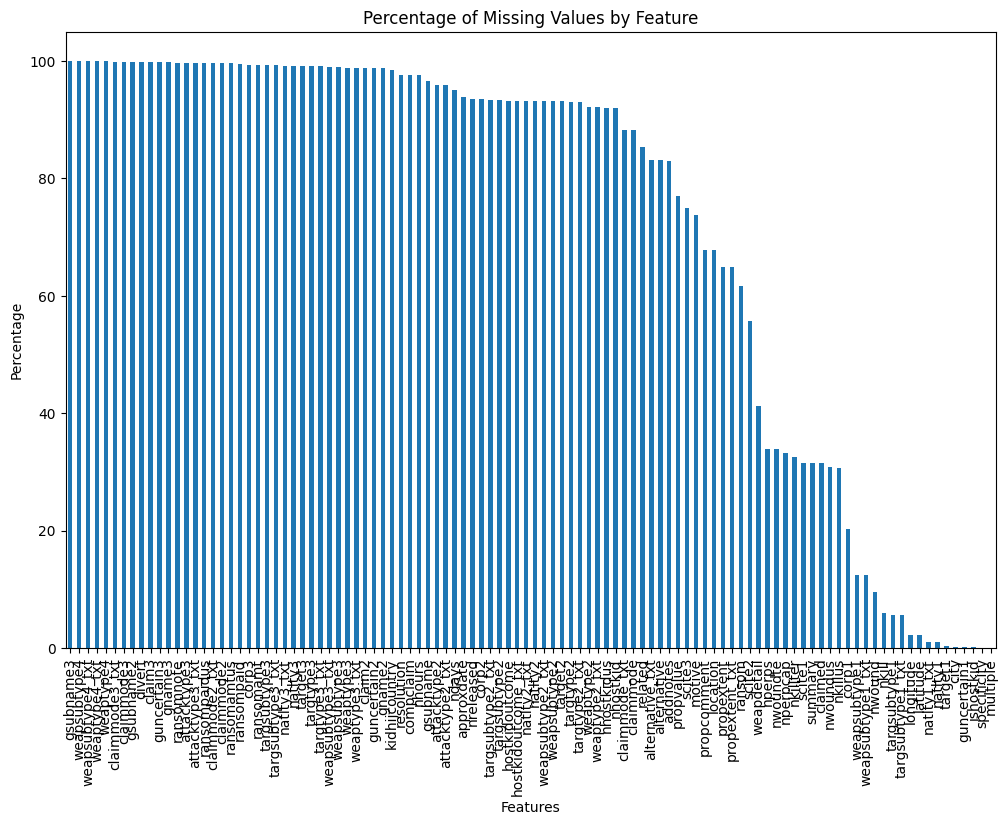

In [8]:


# Bar plot to visualize the percentage of missing data
plt.figure(figsize=(12, 8))
missing_data['Percentage'].plot(kind='bar')
plt.title('Percentage of Missing Values by Feature')
plt.xlabel('Features')
plt.ylabel('Percentage')
plt.show()

In [9]:
# Calculate the percentage of missing values for each feature
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Define the threshold for dropping features
threshold = 90

# Identify features to drop
features_to_drop = missing_percentage[missing_percentage > threshold].index

# Drop the features
df_cleaned = df.drop(columns=features_to_drop)

# Print the shape of the dataset before and after dropping features
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

# Print the names of the dropped features
print("Dropped features:")
print(features_to_drop)

Original dataset shape: (209706, 135)
Cleaned dataset shape: (209706, 73)
Dropped features:
Index(['approxdate', 'resolution', 'attacktype2', 'attacktype2_txt',
       'attacktype3', 'attacktype3_txt', 'targtype2', 'targtype2_txt',
       'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2',
       'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3',
       'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt',
       'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'guncertain2',
       'guncertain3', 'claim2', 'claimmode2', 'claimmode2_txt', 'claim3',
       'claimmode3', 'claimmode3_txt', 'compclaim', 'weaptype2',
       'weaptype2_txt', 'weapsubtype2', 'weapsubtype2_txt', 'weaptype3',
       'weaptype3_txt', 'weapsubtype3', 'weapsubtype3_txt', 'weaptype4',
       'weaptype4_txt', 'weapsubtype4', 'weapsubtype4_txt', 'nhostkid',
       'nhostkidus', 'nhours', 'ndays', 'divert', 'kidhijcountry', 'ransomamt',
       'ransomamtus', 'ransompaid', 

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_1503/1384900983.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_n_values.index, x=top_n_values.values, palette="viridis")


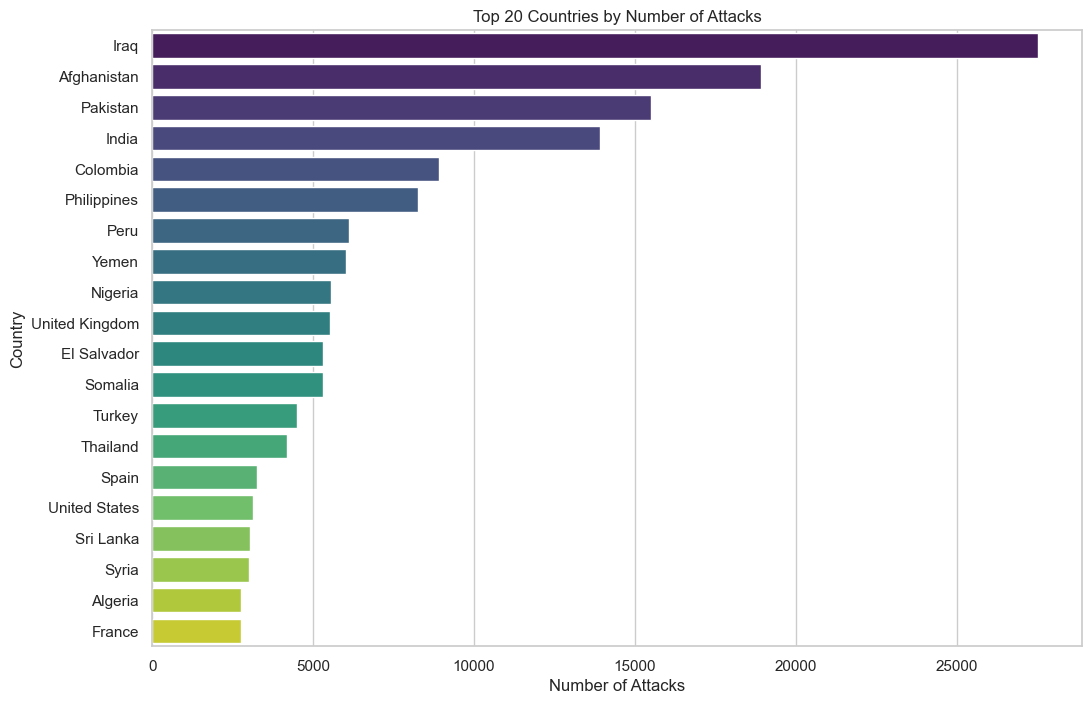

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_1503/1384900983.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_n_values.index, x=top_n_values.values, palette="viridis")


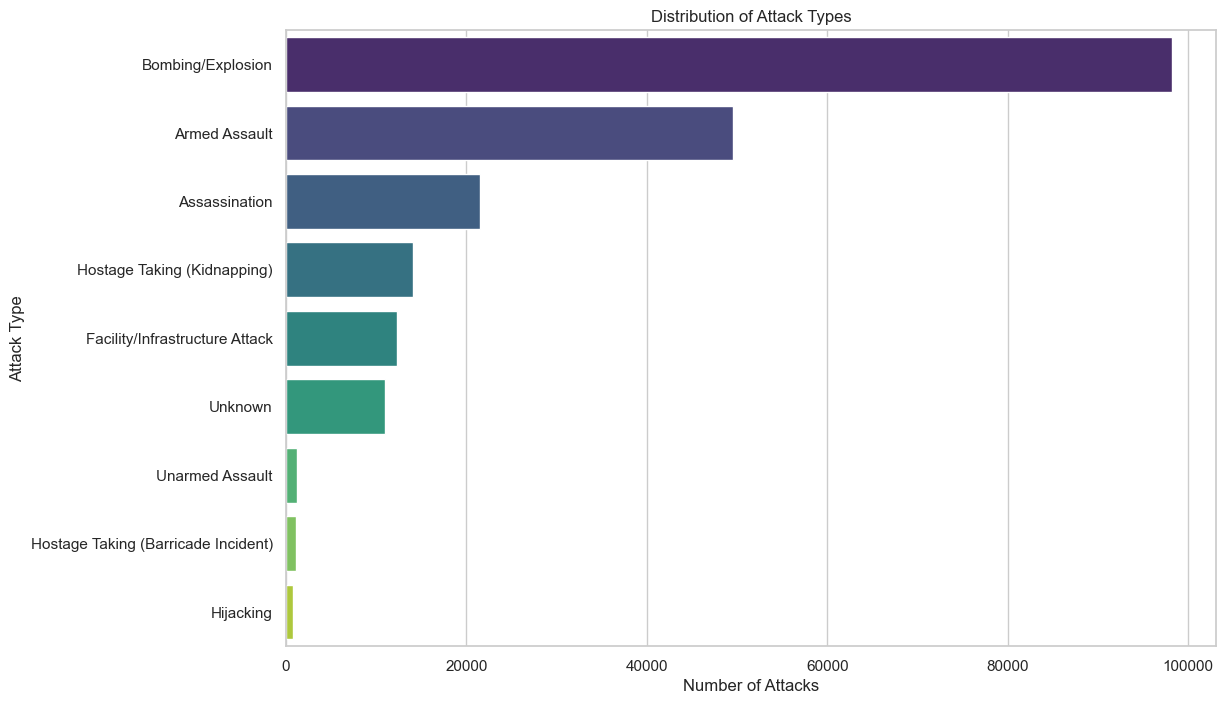

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_1503/1384900983.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_n_values.index, x=top_n_values.values, palette="viridis")


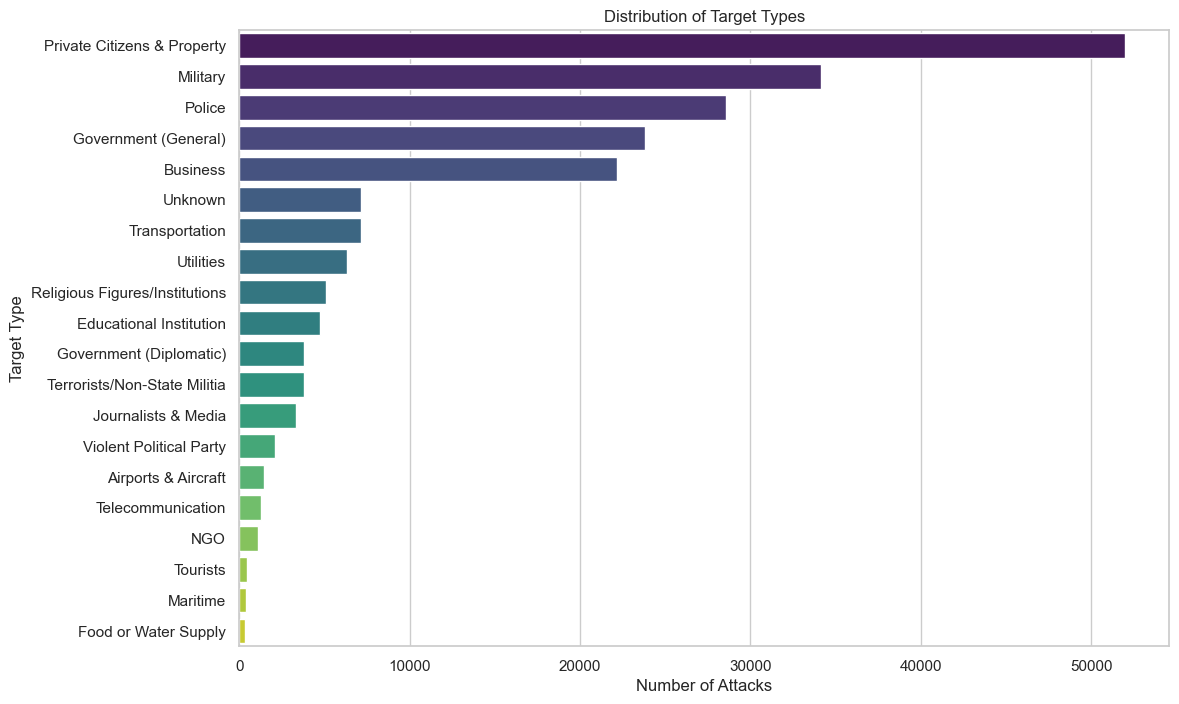

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_1503/1384900983.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_n_values.index, x=top_n_values.values, palette="viridis")


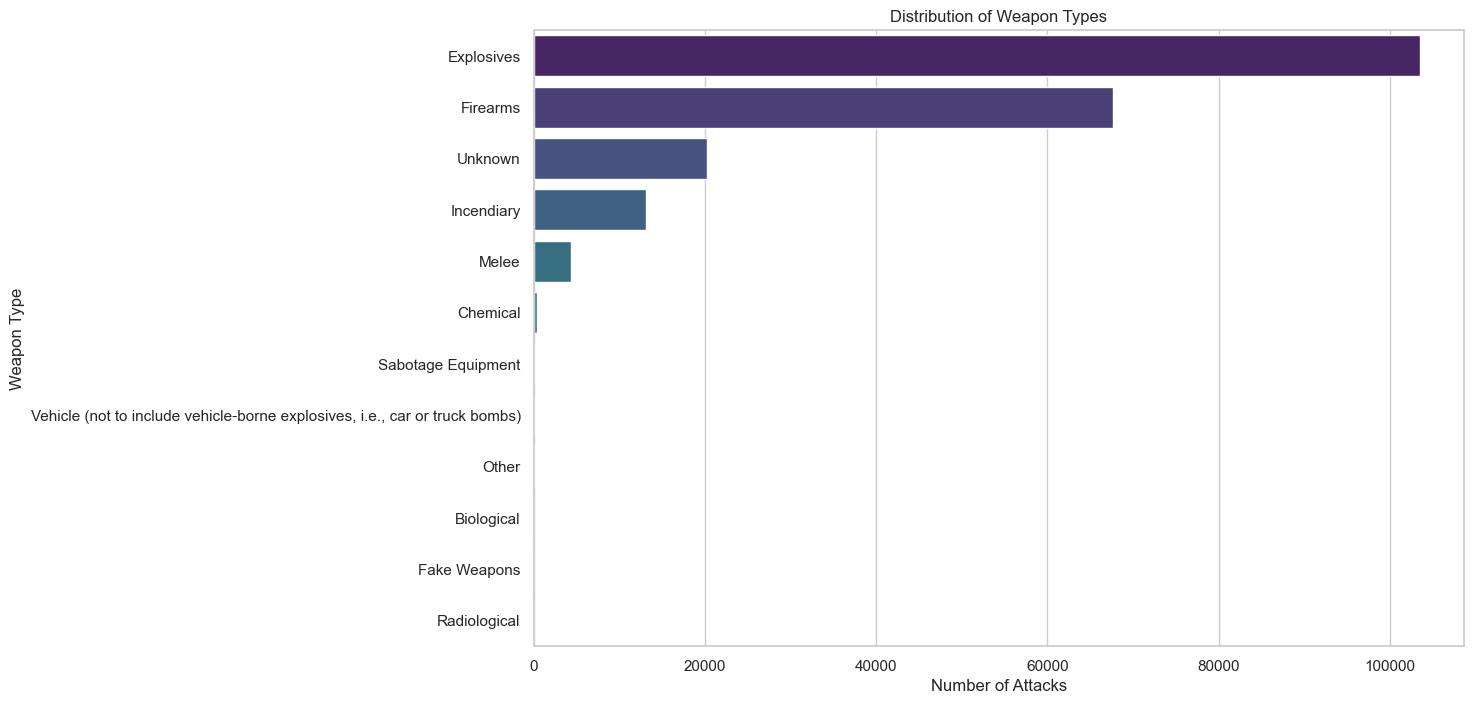

In [10]:

# Set the style for the plots
sns.set(style="whitegrid")

# Function to plot bar plots for top N categorical features
def plot_top_n_categorical_feature(feature, title, xlabel, ylabel, top_n=20):
    plt.figure(figsize=(12, 8))
    top_n_values = df_cleaned[feature].value_counts().nlargest(top_n)
    sns.barplot(y=top_n_values.index, x=top_n_values.values, palette="viridis")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Plotting top N categorical features
plot_top_n_categorical_feature('country_txt', 'Top 20 Countries by Number of Attacks', 'Number of Attacks', 'Country', top_n=20)
plot_top_n_categorical_feature('attacktype1_txt', 'Distribution of Attack Types', 'Number of Attacks', 'Attack Type')
plot_top_n_categorical_feature('targtype1_txt', 'Distribution of Target Types', 'Number of Attacks', 'Target Type')
plot_top_n_categorical_feature('weaptype1_txt', 'Distribution of Weapon Types', 'Number of Attacks', 'Weapon Type')

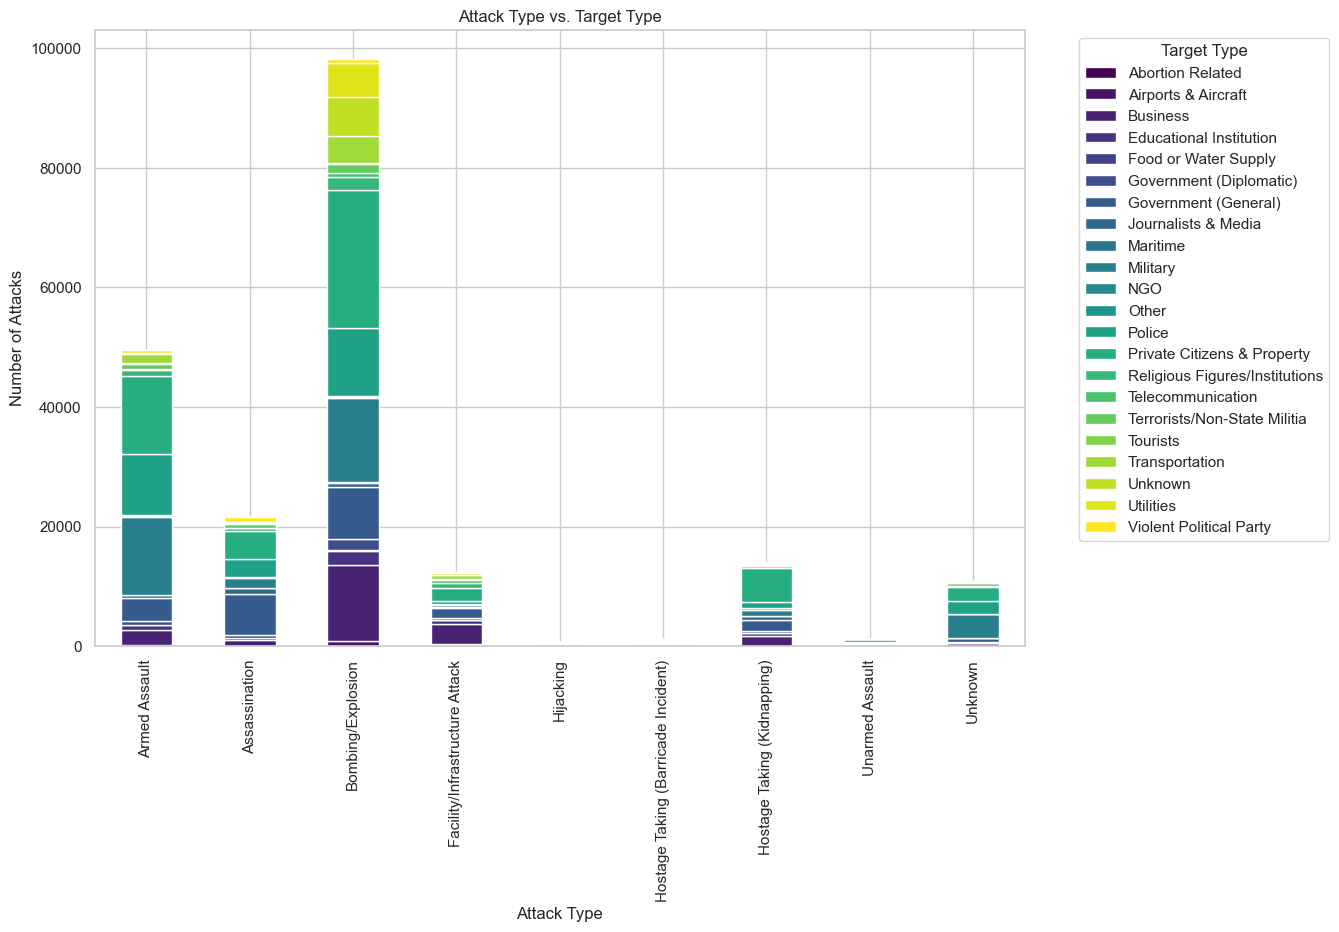

In [11]:
# Cross-tabulation between attack type and target type
crosstab = pd.crosstab(df_cleaned['attacktype1_txt'], df_cleaned['targtype1_txt'])

# Stacked bar plot for attack type vs. target type
crosstab.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')
plt.title('Attack Type vs. Target Type')
plt.xlabel('Attack Type')
plt.ylabel('Number of Attacks')
plt.legend(title='Target Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

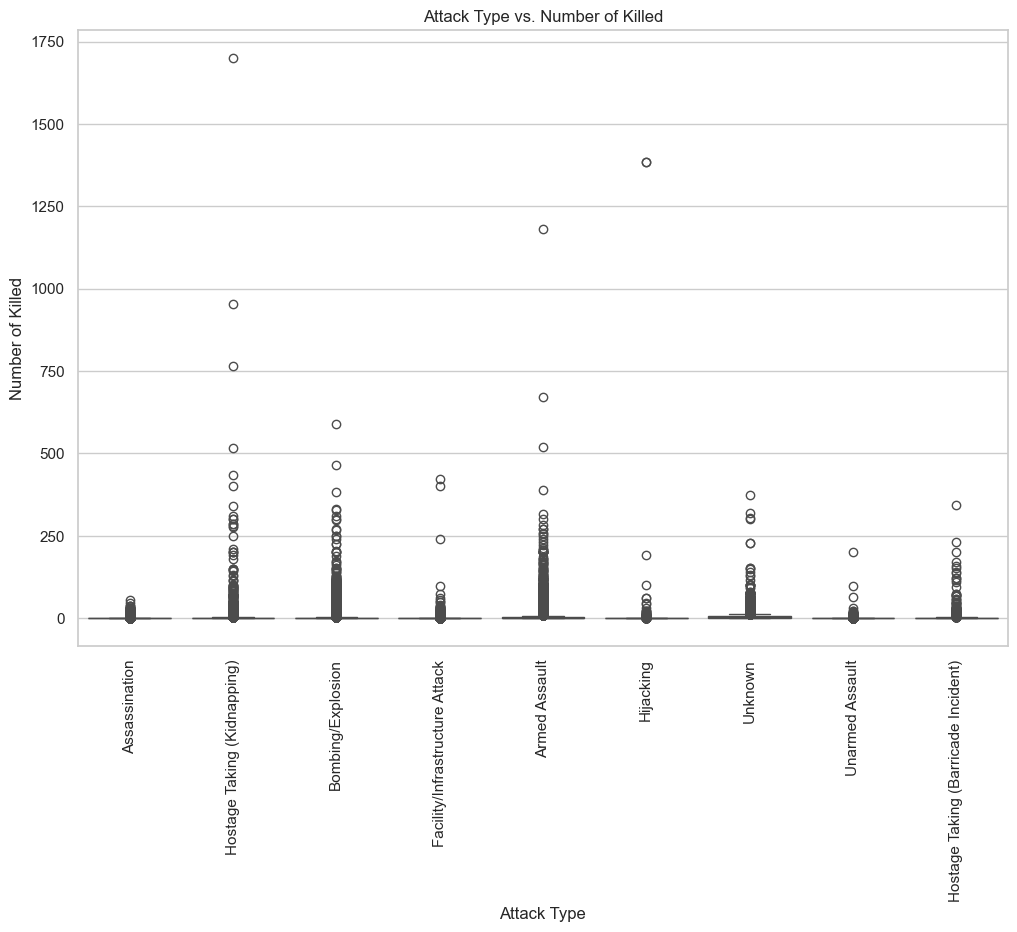

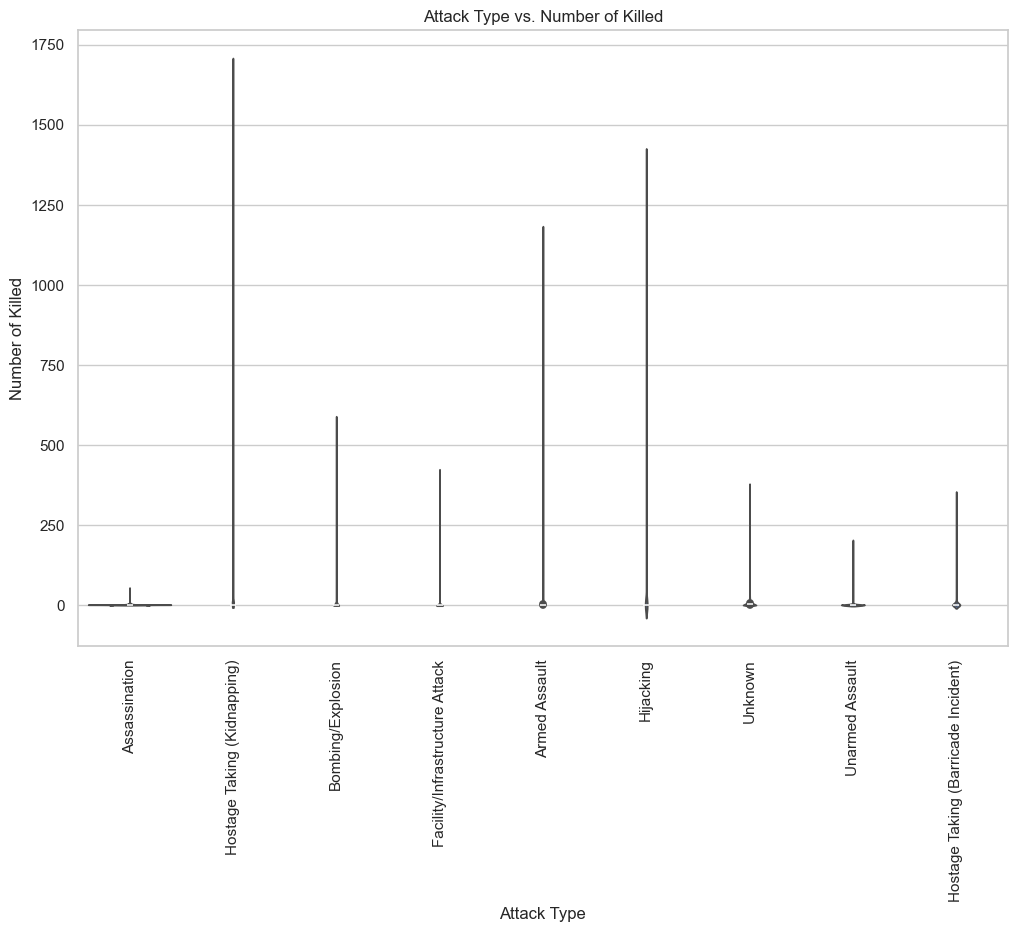

In [12]:
# Box plot for attack type vs. number of killed
plt.figure(figsize=(12, 8))
sns.boxplot(x='attacktype1_txt', y='nkill', data=df_cleaned)
plt.title('Attack Type vs. Number of Killed')
plt.xlabel('Attack Type')
plt.ylabel('Number of Killed')
plt.xticks(rotation=90)
plt.show()

# Violin plot for attack type vs. number of killed
plt.figure(figsize=(12, 8))
sns.violinplot(x='attacktype1_txt', y='nkill', data=df_cleaned)
plt.title('Attack Type vs. Number of Killed')
plt.xlabel('Attack Type')
plt.ylabel('Number of Killed')
plt.xticks(rotation=90)
plt.show()

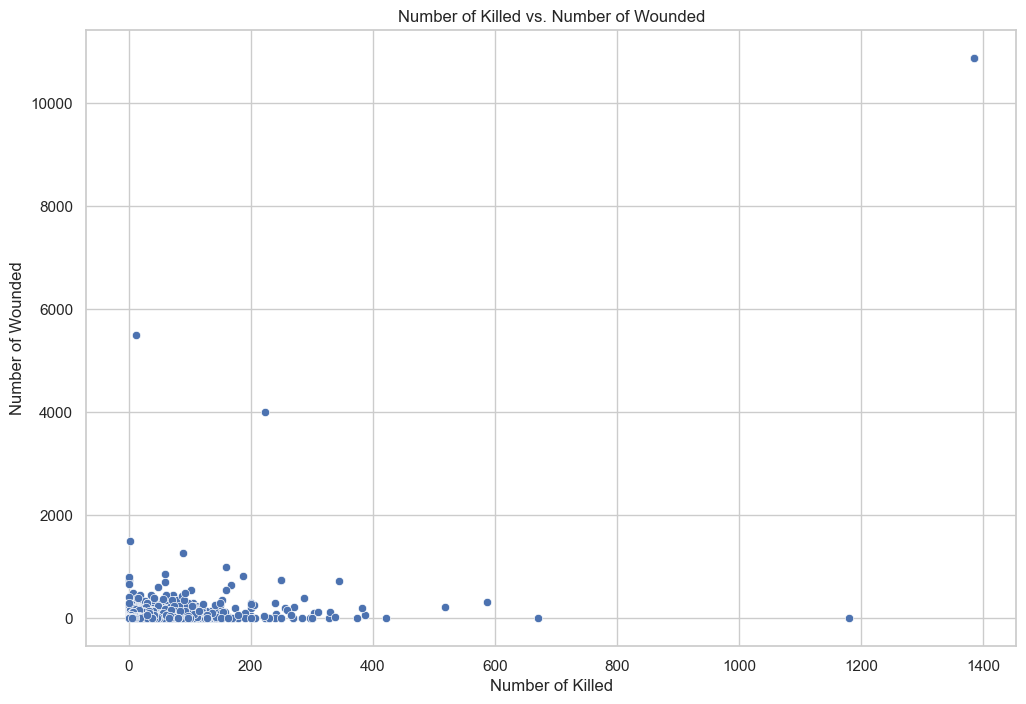

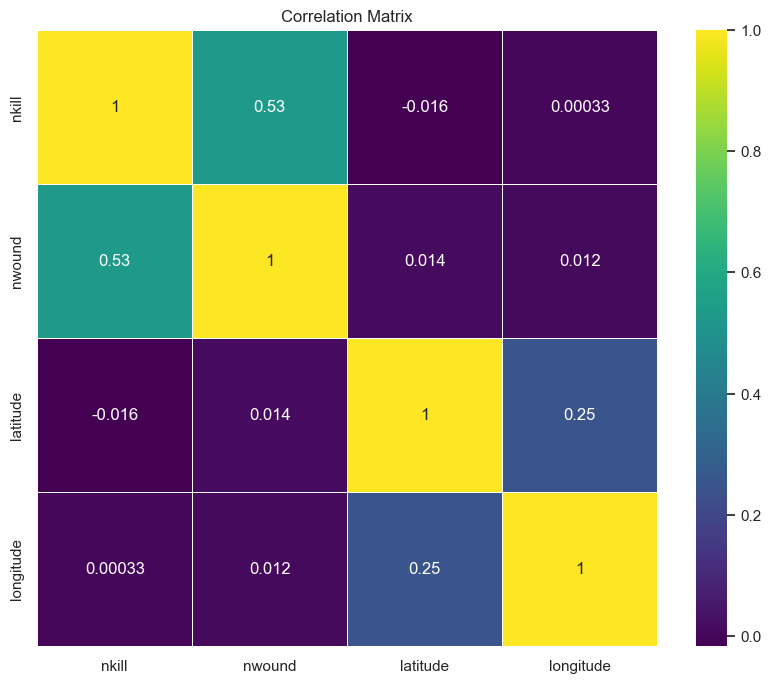

In [13]:
# Scatter plot for number of killed vs. number of wounded
plt.figure(figsize=(12, 8))
sns.scatterplot(x='nkill', y='nwound', data=df_cleaned)
plt.title('Number of Killed vs. Number of Wounded')
plt.xlabel('Number of Killed')
plt.ylabel('Number of Wounded')
plt.show()

# Correlation matrix
correlation_matrix = df_cleaned[['nkill', 'nwound', 'latitude', 'longitude']].corr()

# Heatmap for correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

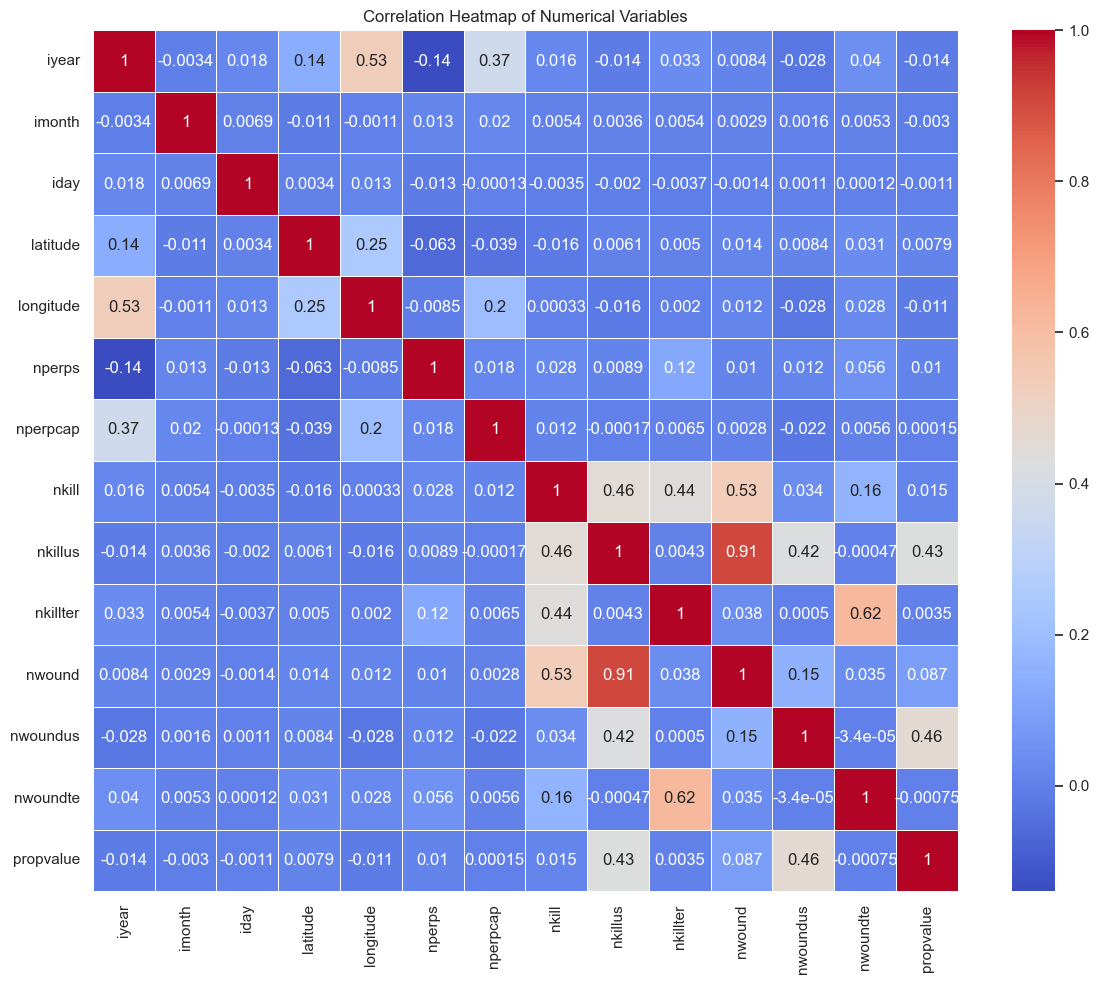

In [14]:
numerical_cols = ['iyear', 'imonth', 'iday', 'latitude', 'longitude', 'nperps', 'nperpcap', 'nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'propvalue']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

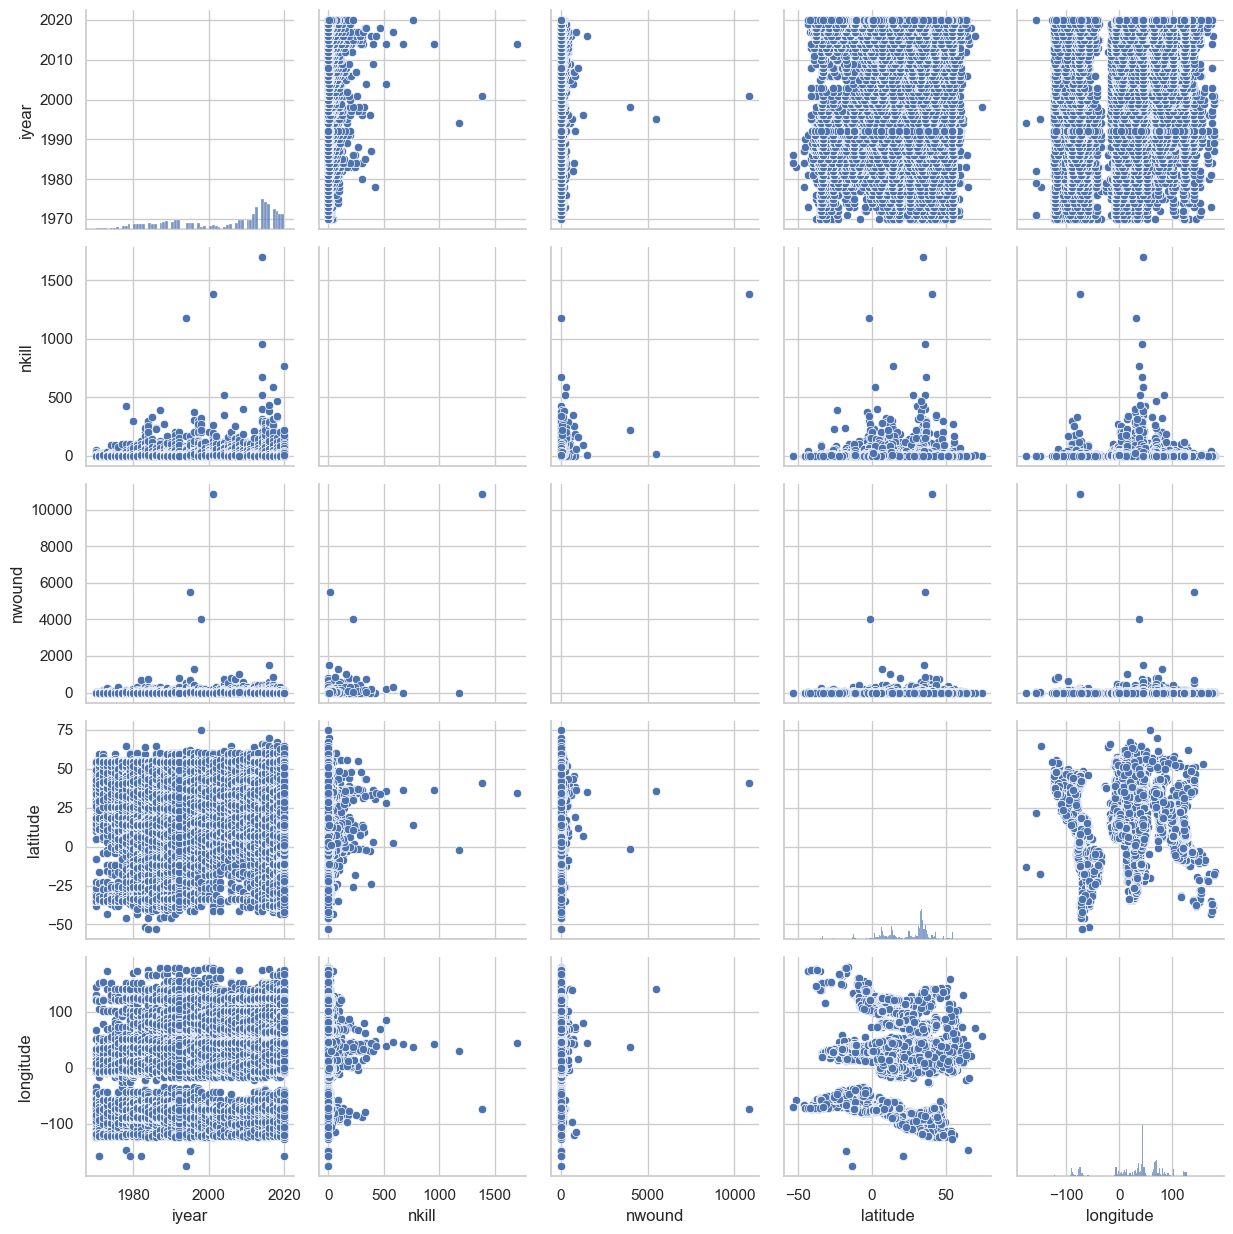

In [15]:
# 2. Pairplot for Key Numerical Variables
key_vars = ['iyear', 'nkill', 'nwound', 'latitude', 'longitude']
sns.pairplot(df_cleaned[key_vars], height=2.5)
plt.tight_layout()
plt.show()

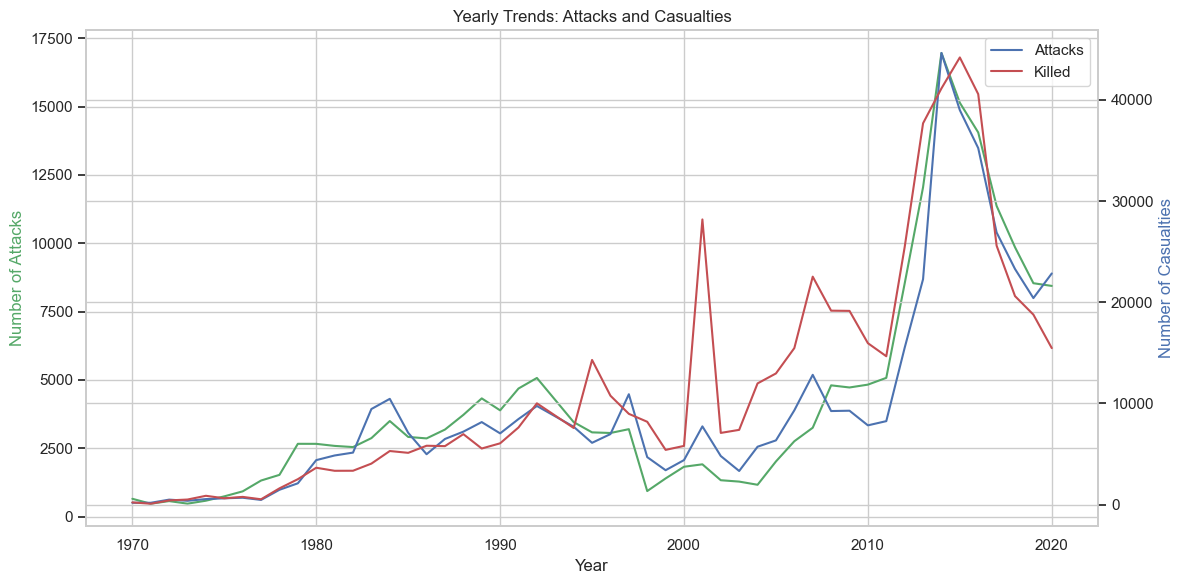

In [16]:
# 3. Time Series Analysis
yearly_attacks = df_cleaned.groupby('iyear').size()
yearly_casualties = df_cleaned.groupby('iyear')[['nkill', 'nwound']].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(yearly_attacks.index, yearly_attacks.values, 'g-')
ax2.plot(yearly_casualties.index, yearly_casualties['nkill'], 'b-')
ax2.plot(yearly_casualties.index, yearly_casualties['nwound'], 'r-')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Attacks', color='g')
ax2.set_ylabel('Number of Casualties', color='b')
plt.title('Yearly Trends: Attacks and Casualties')
plt.legend(['Attacks', 'Killed', 'Wounded'])
plt.tight_layout()
plt.show()

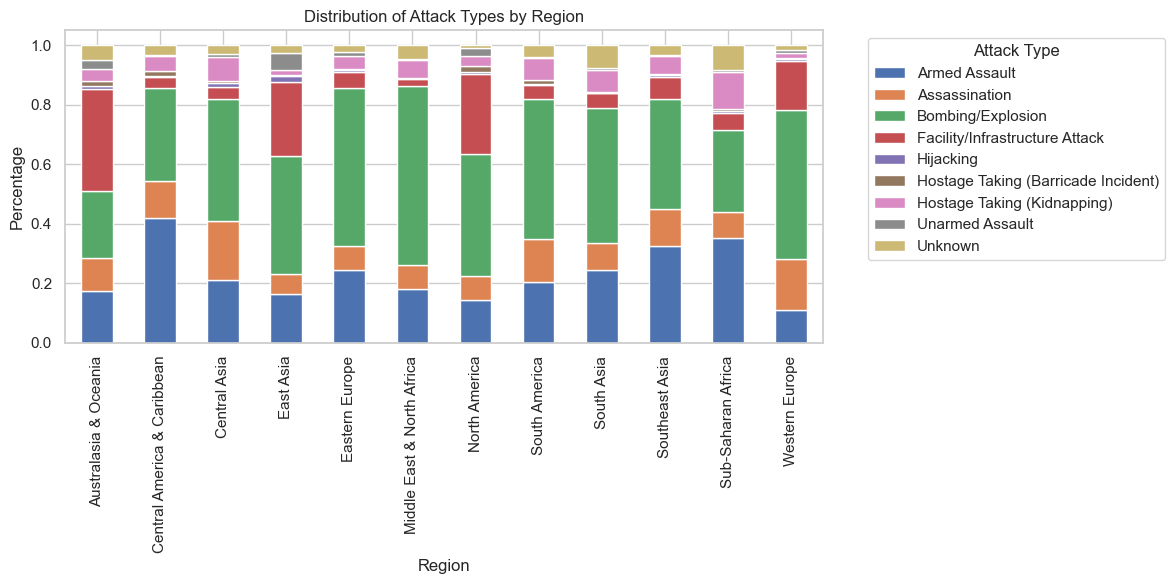

In [17]:

# 4. Stacked Bar Chart: Attack Types by Region
attack_region = pd.crosstab(df_cleaned['region_txt'], df_cleaned['attacktype1_txt'])
attack_region_pct = attack_region.div(attack_region.sum(axis=1), axis=0)
attack_region_pct.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Attack Types by Region')
plt.xlabel('Region')
plt.ylabel('Percentage')
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
df_cleaned = df_cleaned.fillna(0)  # Replace NaN with 0, or use another appropriate method


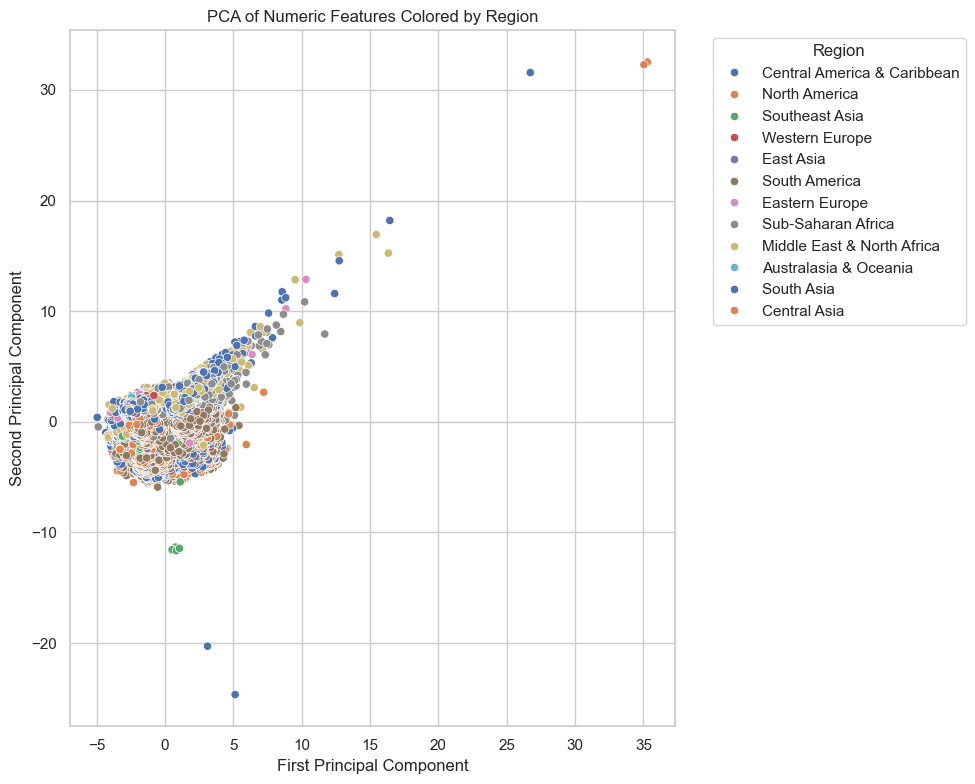

In [19]:

# 6. PCA for Dimensionality Reduction and Visualization
numeric_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
X = df_cleaned[numeric_features]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df_cleaned['region_txt'], palette='deep')
plt.title('PCA of Numeric Features Colored by Region')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.07566497 0.07134049]


Map saved as 'terrorist_attacks_map.html'
Heatmap saved as 'terrorist_attacks_heatmap.html'


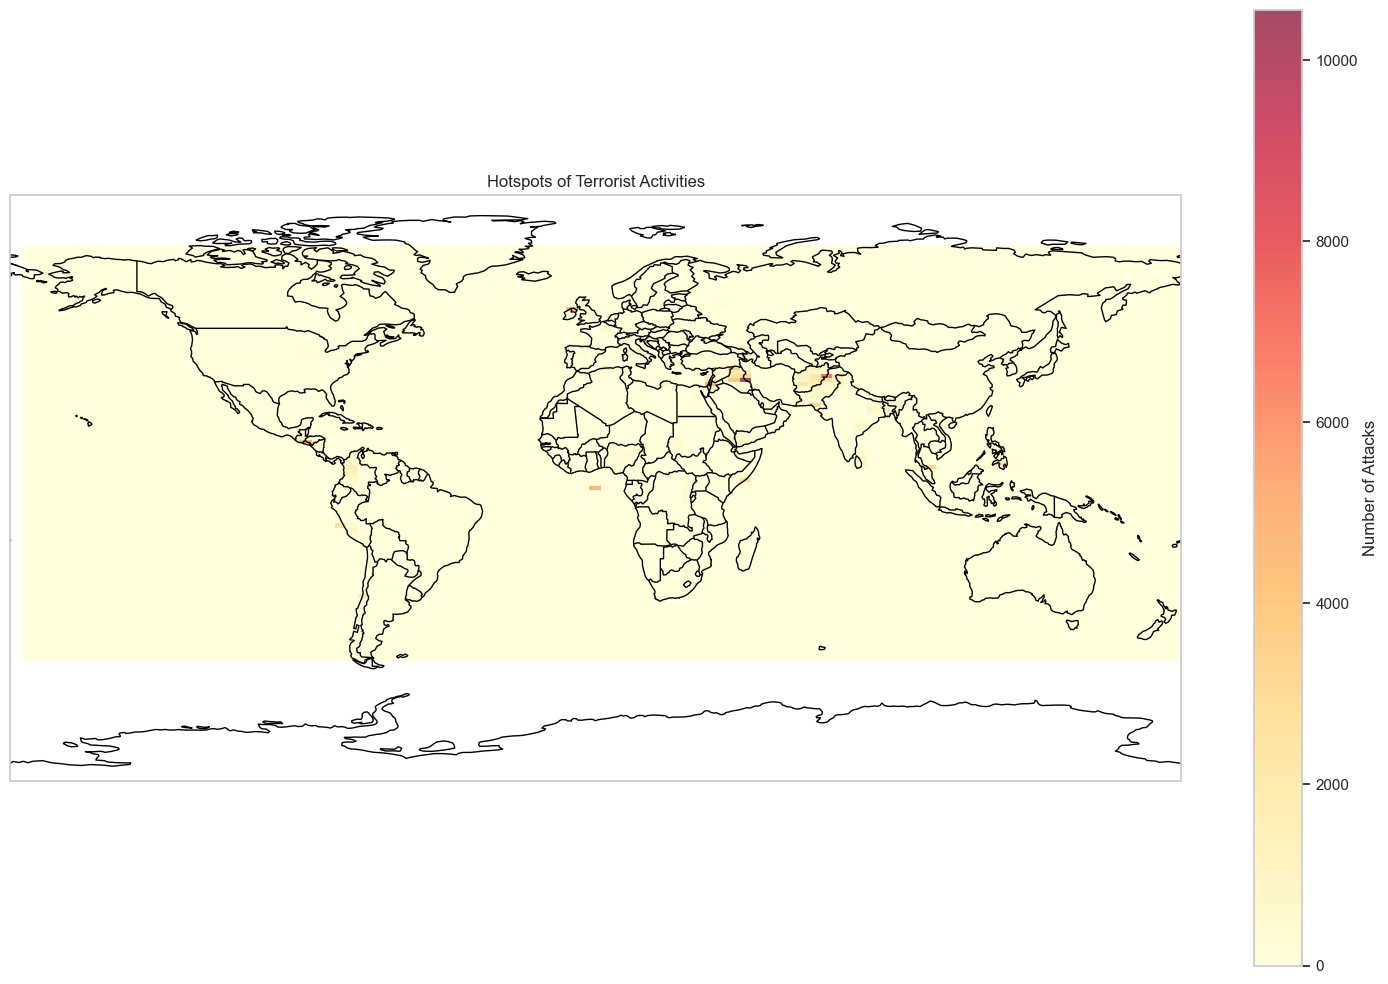

Hotspot analysis map saved as 'terrorist_attacks_hotspots.png'


In [23]:
# 4.1 Geographical Distribution
# Create a base map
m = folium.Map(location=[0, 0], zoom_start=2)

# Create a MarkerCluster
marker_cluster = MarkerCluster().add_to(m)

# Sample data if the dataset is too large
sample_size = min(10000, len(df_cleaned))  # Adjust sample size as needed
df_sample = df_cleaned.sample(n=sample_size, random_state=42)

# Add markers for each attack
for idx, row in df_sample.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Year: {row['iyear']}, Country: {row['country_txt']}, Attack Type: {row['attacktype1_txt']}",
    ).add_to(marker_cluster)

# Save the map
m.save("terrorist_attacks_map.html")
print("Map saved as 'terrorist_attacks_map.html'")

# 4.2 Heatmap
m_heat = folium.Map(location=[0, 0], zoom_start=2)

# Prepare data for heatmap
heat_data = df_sample[['latitude', 'longitude']].values.tolist()

# Add heatmap to the map
HeatMap(heat_data).add_to(m_heat)

# Save the heatmap
m_heat.save("terrorist_attacks_heatmap.html")
print("Heatmap saved as 'terrorist_attacks_heatmap.html'")

# 4.3 Hotspot Analysis using 2D Histogram
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Create 2D histogram
hist = ax.hist2d(df_cleaned['longitude'], df_cleaned['latitude'], 
                 bins=100, cmap='YlOrRd', alpha=0.7, 
                 transform=ccrs.PlateCarree())

# Add colorbar
plt.colorbar(hist[3], ax=ax, label='Number of Attacks')

# Set title and remove axis labels
plt.title('Hotspots of Terrorist Activities')
ax.set_global()  # This ensures the entire world is shown

# Adjust layout and save
plt.tight_layout()
plt.savefig('terrorist_attacks_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Hotspot analysis map saved as 'terrorist_attacks_hotspots.png'")

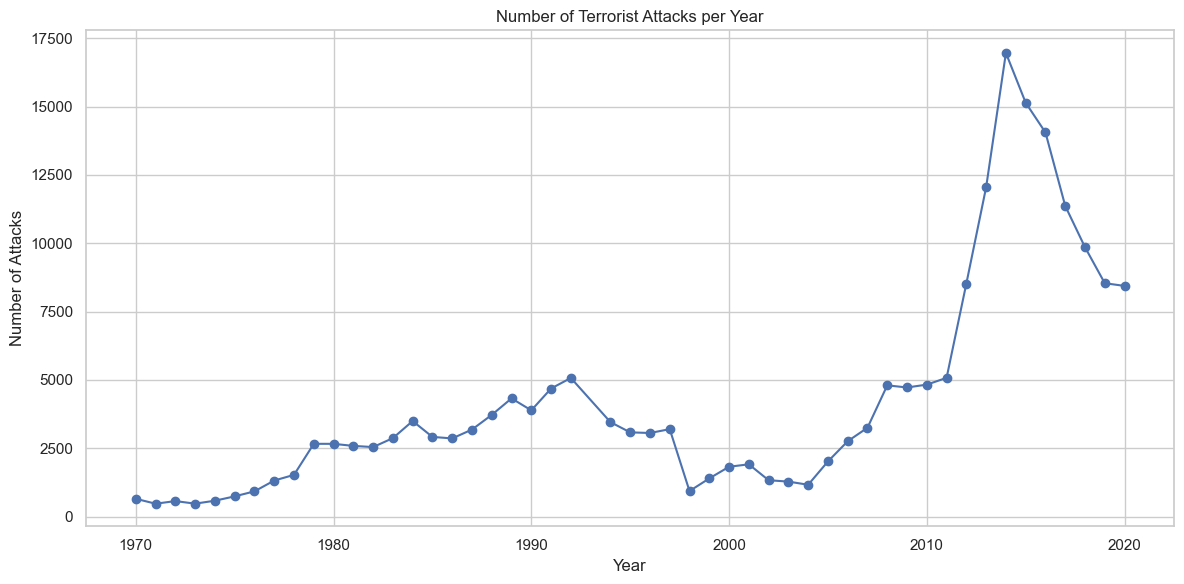

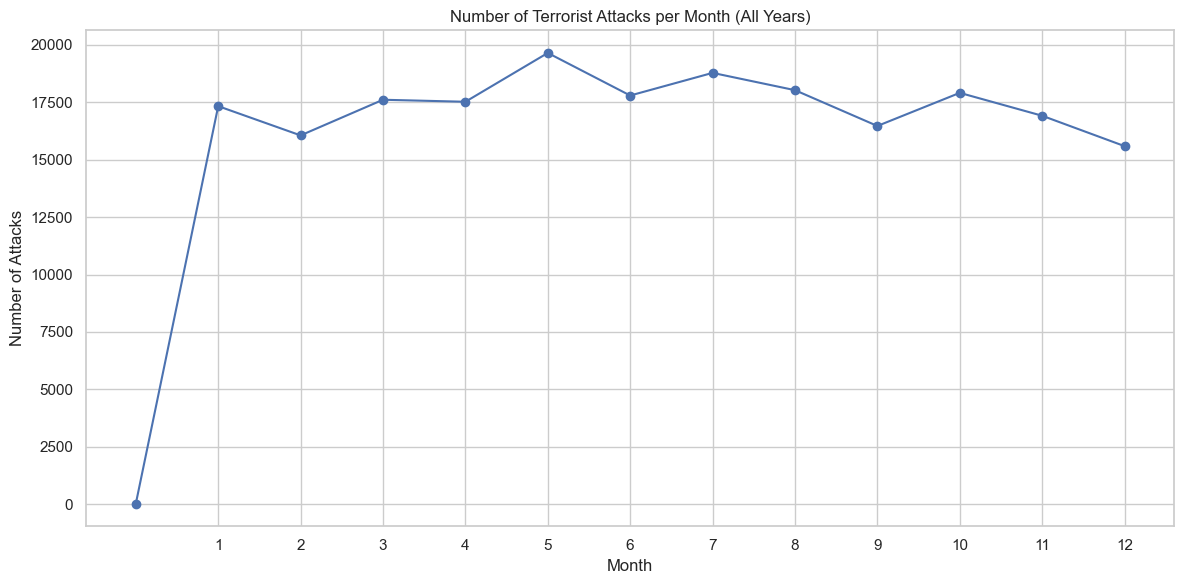

In [24]:

# 5.1 Trend Analysis

# Attacks per year
yearly_attacks = df_cleaned.groupby('iyear').size()
plt.figure(figsize=(12, 6))
yearly_attacks.plot(kind='line', marker='o')
plt.title('Number of Terrorist Attacks per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.tight_layout()
plt.savefig('yearly_attacks_trend.png')
plt.show()

# Attacks per month (aggregated across all years)
monthly_attacks = df_cleaned.groupby('imonth').size()
plt.figure(figsize=(12, 6))
monthly_attacks.plot(kind='line', marker='o')
plt.title('Number of Terrorist Attacks per Month (All Years)')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_attacks_trend.png')
plt.show()

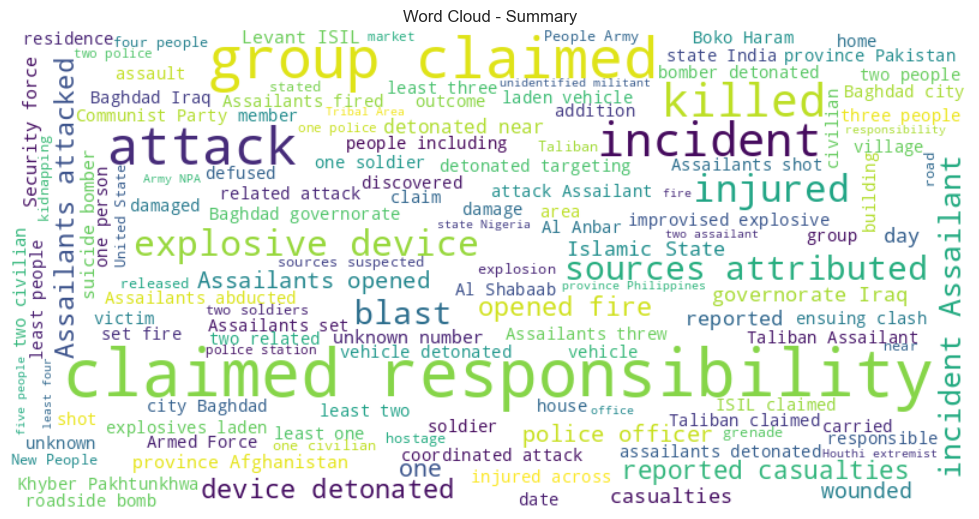

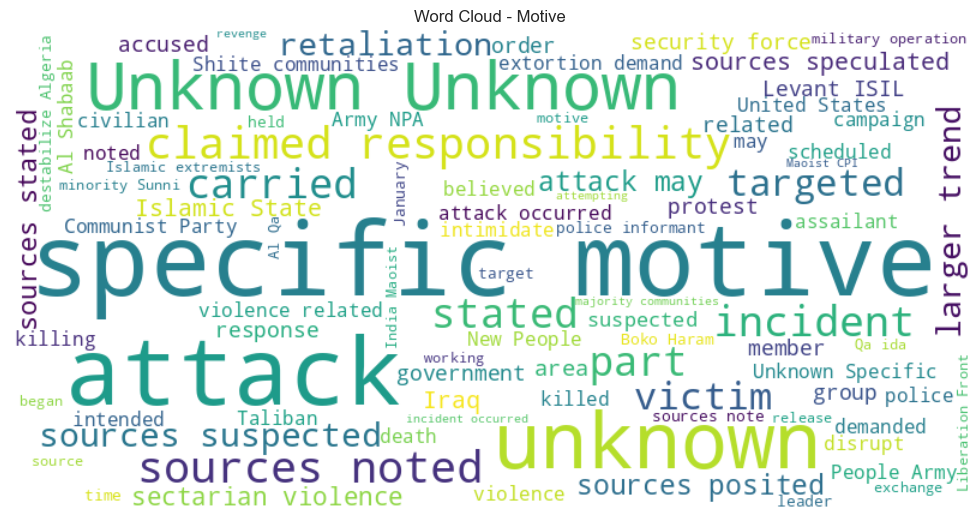

In [25]:
# 6.1 Word Clouds

def generate_wordcloud(text, title):
    # Create and generate a word cloud image
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=STOPWORDS, min_font_size=10).generate(text)
    
    # Display the generated image
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.tight_layout(pad=0)
    plt.savefig(f"{title.lower().replace(' ', '_')}.png")
    plt.show()

# Word Cloud for Summary
summary_text = ' '.join(df_cleaned['summary'].dropna().astype(str))
generate_wordcloud(summary_text, "Word Cloud - Summary")

# Word Cloud for Motive
motive_text = ' '.join(df_cleaned['motive'].dropna().astype(str))
generate_wordcloud(motive_text, "Word Cloud - Motive")


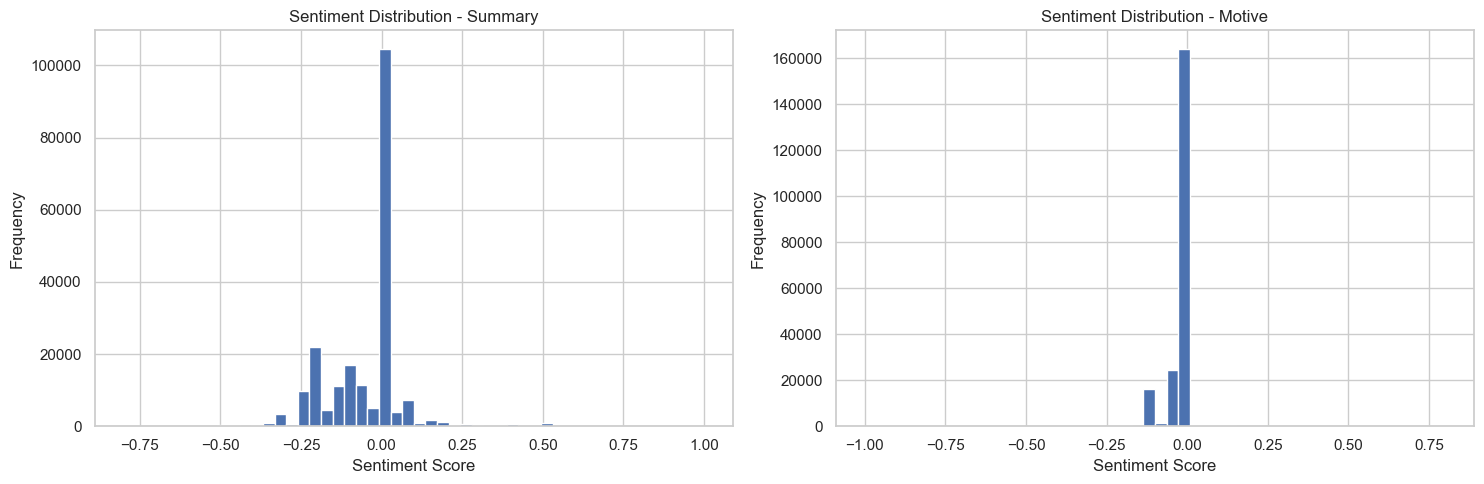

Average sentiment score for Summary: -0.0523
Average sentiment score for Motive: -0.0143


In [ ]:
# 6.2 Sentiment Analysis

def clean_text(text):
    # Convert to string and lowercase
    text = str(text).lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

# Perform sentiment analysis on Summary
df_cleaned['clean_summary'] = df_cleaned['summary'].fillna('').astype(str).apply(clean_text)
df_cleaned['summary_sentiment'] = df_cleaned['clean_summary'].apply(get_sentiment)

# Perform sentiment analysis on Motive
df_cleaned['clean_motive'] = df_cleaned['motive'].fillna('').astype(str).apply(clean_text)
df_cleaned['motive_sentiment'] = df_cleaned['clean_motive'].apply(get_sentiment)

# Visualize sentiment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df_cleaned['summary_sentiment'], bins=50)
ax1.set_title('Sentiment Distribution - Summary')
ax1.set_xlabel('Sentiment Score')
ax1.set_ylabel('Frequency')

ax2.hist(df_cleaned['motive_sentiment'], bins=50)
ax2.set_title('Sentiment Distribution - Motive')
ax2.set_xlabel('Sentiment Score')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

# Print average sentiment scores
print(f"Average sentiment score for Summary: {df_cleaned['summary_sentiment'].mean():.4f}")
print(f"Average sentiment score for Motive: {df_cleaned['motive_sentiment'].mean():.4f}")

In [ ]:

# Top 10 most positive and negative summaries
top_positive_summaries = df_cleaned.nlargest(10, 'summary_sentiment')[['summary', 'summary_sentiment']]
top_negative_summaries = df_cleaned.nsmallest(10, 'summary_sentiment')[['summary', 'summary_sentiment']]

print("\nTop 10 Most Positive Summaries:")
print(top_positive_summaries)

print("\nTop 10 Most Negative Summaries:")
print(top_negative_summaries)



Top 10 Most Positive Summaries:
                                                  summary  summary_sentiment
201864  01/30/2020: Assailants firebombed a Best Mart ...                1.0
69722   11/18/1999: Unidentified assailants of the Gre...                0.8
69943   01/16/2000: A bomb exploded at the Hurriyet Me...                0.8
71693   01/08/2001: A professor at the Marmara Univers...                0.8
71845   02/05/2001: Six civilians were injured after a...                0.8
71877   2/12/2001: Suspected animal rights activists s...                0.8
79591   01/27/2006: Fatah-aligned protesters converged...                0.8
79731   02/06/2006: Security forces stopped a suspecte...                0.8
81333   08/13/2006: The Taliban ambushed the police in...                0.8
87494   06/19/2008: On Thursday, at 2300, suspected mi...                0.8

Top 10 Most Negative Summaries:
                                                 summary  summary_sentiment
67683  03/0

In [ ]:
images_dir = '/Users/ramdevpm/Terrorist Classifier/images'


In [ ]:

# Select numerical features for outlier detection
numerical_features = ['nkill', 'nwound', 'nperps', 'nperpcap']

# Create box plots
plt.figure(figsize=(12, 6))
df_cleaned[numerical_features].boxplot()
plt.title('Box Plots of Numerical Features')
plt.ylabel('Value')
plt.yscale('log')  # Use log scale for better visualization
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'boxplot_outliers.png'))
plt.close()

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='nkill', y='nwound')
plt.title('Scatter Plot: Number Killed vs Number Wounded')
plt.xlabel('Number Killed')
plt.ylabel('Number Wounded')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'scatterplot_outliers.png'))
plt.close()

In [ ]:
# 7.2 Analyze Outliers

def identify_outliers(df, column, threshold=3):
    z_scores = stats.zscore(df[column])
    return df[abs(z_scores) > threshold]

# Identify outliers for each numerical feature
outliers = {}
for feature in numerical_features:
    outliers[feature] = identify_outliers(df_cleaned, feature)

# Print summary of outliers
print("Number of outliers detected:")
for feature, outlier_df in outliers.items():
    print(f"{feature}: {len(outlier_df)}")

# Analyze top 10 outliers for each feature
for feature, outlier_df in outliers.items():
    print(f"\nTop 10 outliers for {feature}:")
    top_10_outliers = outlier_df.nlargest(10, feature)
    print(top_10_outliers[['iyear', 'country_txt', 'city', feature, 'summary']])

# 7.3 Visualize outliers on a world map
plt.figure(figsize=(15, 10))

# Download and read the world map data
world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

world.plot(color='lightgrey', edgecolor='black')

# Plot all events
plt.scatter(df_cleaned['longitude'], df_cleaned['latitude'], 
            color='blue', alpha=0.1, s=1)

# Plot outlier events
outlier_events = pd.concat(outliers.values()).drop_duplicates()
plt.scatter(outlier_events['longitude'], outlier_events['latitude'], 
            color='red', alpha=0.5, s=10)

plt.title('Geographical Distribution of Terrorist Events (Outliers in Red)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'outliers_world_map.png'))
plt.close()

print("Outlier analysis completed and visualizations saved in the 'images' folder.")

Number of outliers detected:
nkill: 1549
nwound: 327
nperps: 186
nperpcap: 2116

Top 10 outliers for nkill:
        iyear    country_txt              city   nkill  \
133556   2014           Iraq            Tikrit  1700.0   
73134    2001  United States     New York City  1385.0   
73135    2001  United States     New York City  1385.0   
55930    1994         Rwanda            Gikoro  1180.0   
136326   2014           Iraq            Sinjar   953.0   
208598   2020       Ethiopia        May Cadera   766.0   
133262   2014           Iraq            Badush   670.0   
180794   2017        Somalia         Mogadishu   588.0   
76359    2004          Nepal  Dhading district   518.0   
136790   2014          Syria           Unknown   517.0   

                                                  summary  
133556  06/12/2014: Assailants abducted an unknown num...  
73134   09/11/2001: This was one of four related attac...  
73135   09/11/2001: This was one of four related attac...  
55930        

<Figure size 1500x1000 with 0 Axes>

Cluster Profiles:
               nkill        nwound   latitude  longitude
cluster                                                 
0           2.540503      2.181163   5.939112  55.204834
1        1385.000000  10878.000000  40.697132 -73.931351
2           1.534861      0.887817   3.560042 -79.467377
3           1.920795      3.060177  35.290103  47.179303
4         161.896970    122.996970  19.336064  25.098423


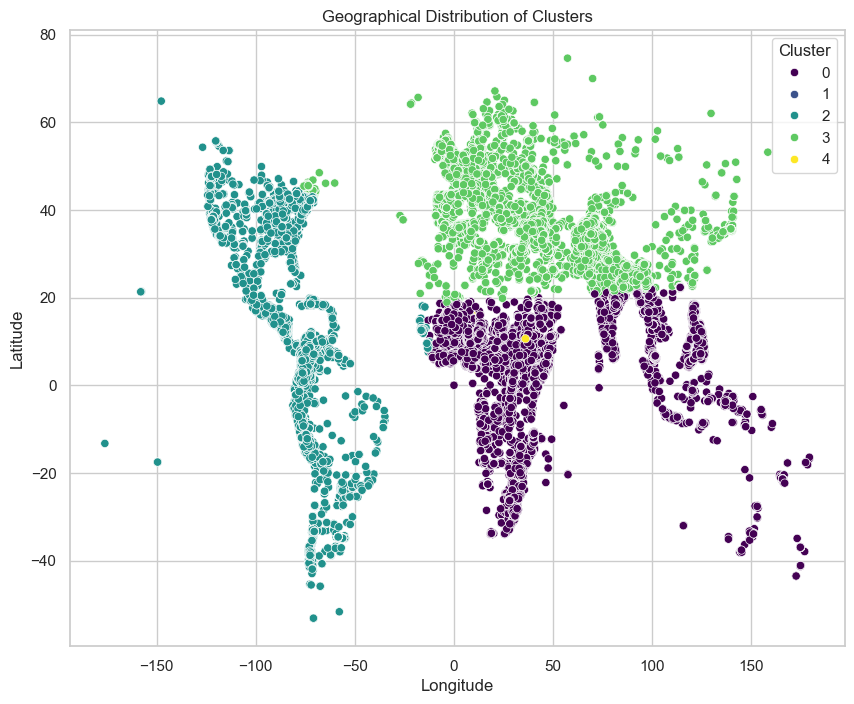

In [26]:

# Select features for clustering
features = ['nkill', 'nwound', 'latitude', 'longitude']
X = df_cleaned[features].fillna(0)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust the number of clusters as needed
df_cleaned['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze Clusters
cluster_profiles = df_cleaned.groupby('cluster')[features].mean()
print("Cluster Profiles:")
print(cluster_profiles)

# Visualize Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='cluster', data=df_cleaned, palette='viridis')
plt.title('Geographical Distribution of Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.show()

Cluster Profiles:
             nkill     nwound   latitude  longitude  gname_encoded
cluster                                                           
0         1.697570   2.390083  23.246078  79.369758    3375.329469
1         1.330256   2.617361  38.005789  32.177472    3333.153299
2        17.401341  14.835796  19.521729 -53.217761    1344.075762
3         1.868068   2.405874  23.386878  44.069976    1099.860009
4         1.284710   1.011342  -2.612216 -51.012359    3077.602760


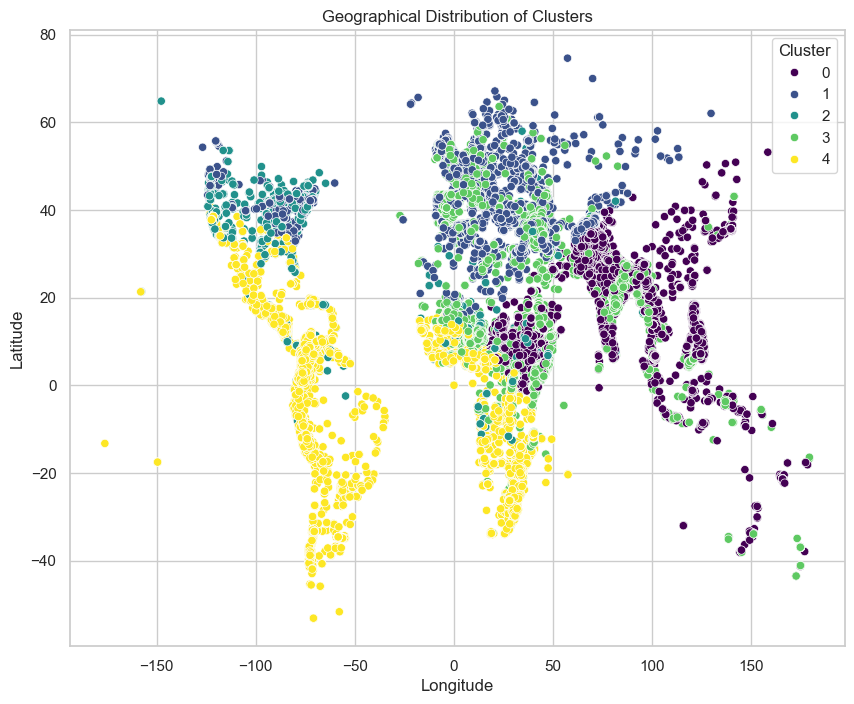

In [27]:
# Select features for clustering
features = ['nkill', 'nwound', 'latitude', 'longitude', 'gname']
df_cleaned = df_cleaned[features].fillna(0)

# Encode the terrorist group names
label_encoder = LabelEncoder()
df_cleaned['gname_encoded'] = label_encoder.fit_transform(df_cleaned['gname'])

# Select features for clustering including the encoded terrorist group
features_for_clustering = ['nkill', 'nwound', 'latitude', 'longitude', 'gname_encoded']
X = df_cleaned[features_for_clustering]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust the number of clusters as needed
df_cleaned['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze Clusters
cluster_profiles = df_cleaned.groupby('cluster')[features_for_clustering].mean()
print("Cluster Profiles:")
print(cluster_profiles)

# Visualize Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='cluster', data=df_cleaned, palette='viridis')
plt.title('Geographical Distribution of Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.show()

Cluster Profiles:
             nkill     nwound   latitude  longitude  gname_encoded
cluster                                                           
0         1.697570   2.390083  23.246078  79.369758    3375.329469
1         1.330256   2.617361  38.005789  32.177472    3333.153299
2        17.401341  14.835796  19.521729 -53.217761    1344.075762
3         1.868068   2.405874  23.386878  44.069976    1099.860009
4         1.284710   1.011342  -2.612216 -51.012359    3077.602760


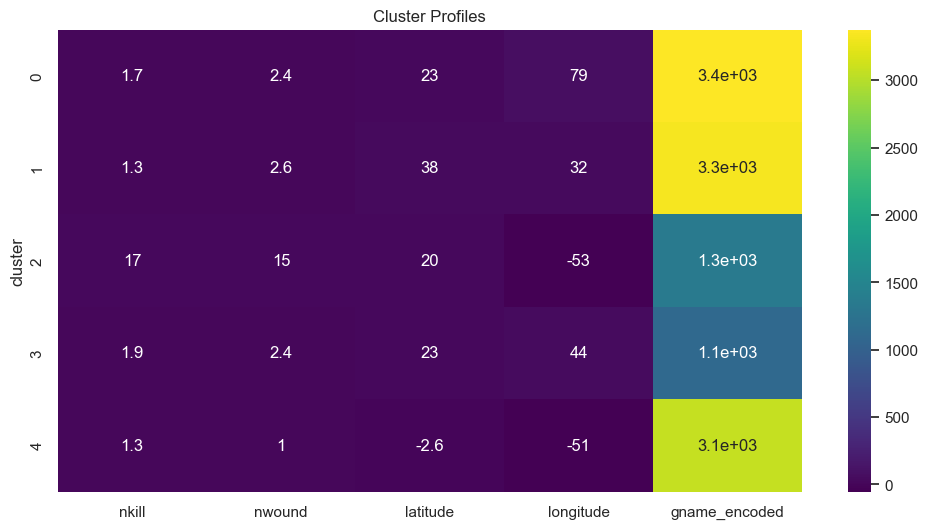

In [28]:
# Analyze Clusters
cluster_profiles = df_cleaned.groupby('cluster')[features_for_clustering].mean()
print("Cluster Profiles:")
print(cluster_profiles)

# Visualize Cluster Profiles
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='viridis')
plt.title('Cluster Profiles')
plt.show()